# Data Cleaning

#### Datasets:
 - Boarding 2 or More Oceans: number_of_bordering_oceans-adjusted.csv
 - Every Border Combination: border_info-adjusted.csv
 - Population Living in Slums: API_EN.POP.SLUM.UR.ZS_DS2_en_csv_v2_336620-adjusted.csv
 - Children in Employment, total: API_SL.TLF.0714.ZS_DS2_en_csv_v2_326798-adjusted.csv
 - Surface Area: API_AG.SRF.TOTL.K2_DS2_en_csv_v2_332041-adjusted.csv
 - Population: API_SP.POP.TOTL_DS16_en_csv_v2_339790-adjusted.csv
 - GNI per Capita: API_NY.GNP.PCAP.CD_DS2_en_csv_v2_276956-adjusted.csv
 - World Bank Classification Thresholds: hie_threshold-adjusted.csv

#### Conversions
 - Bordering 2 or More Oceans -> Binary
 - Every Border Combination -> Discrete Number of Borders
 - Population Living in Slums -> Continuous
 - Children in Employment -> Continuous
 - Size: Surface Area + Population -> Discrete (small, medium, large) (use clustering)
 - GNI per Capita -> Use the World Bank Classification Thresholds to make it binary

### Packages

In [23]:
import pandas as pd
import janitor, re, random
from os import listdir
import matplotlib.pyplot as plt
import seaborn as sns

random.seed(123)

### Basic Data Analysis for WDI Data

In [24]:
wdi_files = [f for f in listdir('Datasets') if re.search("^API.*-adjusted.csv$", f)]
temp_df_1 = pd.DataFrame()
for file in wdi_files:
    df = pd.read_csv(f'Datasets/{file}')
    # print(df)
    indicator_name = df.iloc[1, 2]
    df = df.drop(['Country Code', 'Indicator Name', 'Indicator Code', 'Unnamed: 70', 'code'], axis = 1)
    df_long = df.pivot_longer(index = 'country', names_to = 'year', values_to = indicator_name)
    if temp_df_1.shape[0] == 0:
        temp_df_1 = df_long
    else:
        temp_df_1 = pd.merge(temp_df_1, df_long, on = ['country', 'year'], how = 'left')

temp_df_1['year'] = pd.to_numeric(temp_df_1['year'])
temp_df_1 = temp_df_1[temp_df_1['year'] >= 1987]
temp_df_1 = temp_df_1[temp_df_1['year'] < 2025]
temp_df_1['GNI per capita, Atlas method (current US$)'] = pd.to_numeric(temp_df_1['GNI per capita, Atlas method (current US$)'])
temp_df_1

,country,year,"Children in employment, total (% of children ages 7-14)","GNI per capita, Atlas method (current US$)","Population, total",Surface area (sq. km),Population living in slums (% of urban population)
5859,Afghanistan,1987,NaN,NaN,11387818.0,652860.0,NaN
5860,Albania,1987,NaN,730.0,3083605.0,28750.0,NaN
5861,Algeria,1987,NaN,2850.0,23443624.0,2381740.0,NaN
5862,American Samoa,1987,NaN,NaN,42072.0,200.0,NaN
5863,Andorra,1987,NaN,NaN,47653.0,470.0,NaN
...,...,...,...,...,...,...,...
14100,Virgin Islands,2024,NaN,NaN,104377.0,NaN,NaN
14101,West Bank And Gaza,2024,NaN,2710.0,5289152.0,NaN,NaN
14102,Yemen,2024,NaN,NaN,40583164.0,NaN,NaN
14103,Zambia,2024,NaN,1220.0,21314956.0,NaN,NaN


##### Getting HIE Binary

In [25]:
cutoffs_df = pd.read_csv('Datasets/hie_threshold.csv')[['Year', 'GNI per capita (US$)']]
cutoffs_df.set_index('Year', drop = True, inplace = True)
cutoffs_df['GNI per capita (US$)'] = pd.to_numeric(cutoffs_df['GNI per capita (US$)'].str.replace(',', ''))
cutoffs = cutoffs_df['GNI per capita (US$)'].to_dict()

temp_df_2 = temp_df_1.copy()
temp_df_2['hie'] = temp_df_2.apply(lambda x: True if x['GNI per capita, Atlas method (current US$)'] > cutoffs[x['year']] else False, axis = 1)
temp_df_2

,country,year,"Children in employment, total (% of children ages 7-14)","GNI per capita, Atlas method (current US$)","Population, total",Surface area (sq. km),Population living in slums (% of urban population),hie
5859,Afghanistan,1987,NaN,NaN,11387818.0,652860.0,NaN,False
5860,Albania,1987,NaN,730.0,3083605.0,28750.0,NaN,False
5861,Algeria,1987,NaN,2850.0,23443624.0,2381740.0,NaN,False
5862,American Samoa,1987,NaN,NaN,42072.0,200.0,NaN,False
5863,Andorra,1987,NaN,NaN,47653.0,470.0,NaN,False
...,...,...,...,...,...,...,...,...
14100,Virgin Islands,2024,NaN,NaN,104377.0,NaN,NaN,False
14101,West Bank And Gaza,2024,NaN,2710.0,5289152.0,NaN,NaN,False
14102,Yemen,2024,NaN,NaN,40583164.0,NaN,NaN,False
14103,Zambia,2024,NaN,1220.0,21314956.0,NaN,NaN,False


##### Bordering Data

In [26]:
oceans_border_count = pd.read_csv('Datasets/number_of_bordering_oceans-adjusted.csv')
oceans_border_count = oceans_border_count['country']
oceans_border_count_list = oceans_border_count.to_list()
oceans_border_count_list

temp_df_3 = temp_df_2.copy()
temp_df_3['near_2_plus_oceans'] = temp_df_3['country'].apply(lambda x: True if x in oceans_border_count_list else False)

border_df = pd.read_csv('Datasets/border_info-adjusted.csv')
border_df = border_df.drop(['Unnamed: 0'], axis = 1)
border_df_counts = border_df.groupby('country')['country_border_name'].count()
border_df_counts_dict = border_df_counts.to_dict()

temp_df_3['border_count'] = temp_df_3['country'].apply(lambda x: border_df_counts_dict[x] if x in border_df_counts_dict.keys() else None)
temp_df_3

,country,year,"Children in employment, total (% of children ages 7-14)","GNI per capita, Atlas method (current US$)","Population, total",Surface area (sq. km),Population living in slums (% of urban population),hie,near_2_plus_oceans,border_count
5859,Afghanistan,1987,NaN,NaN,11387818.0,652860.0,NaN,False,False,6.0
5860,Albania,1987,NaN,730.0,3083605.0,28750.0,NaN,False,False,4.0
5861,Algeria,1987,NaN,2850.0,23443624.0,2381740.0,NaN,False,False,7.0
5862,American Samoa,1987,NaN,NaN,42072.0,200.0,NaN,False,False,0.0
5863,Andorra,1987,NaN,NaN,47653.0,470.0,NaN,False,False,2.0
...,...,...,...,...,...,...,...,...,...,...
14100,Virgin Islands,2024,NaN,NaN,104377.0,NaN,NaN,False,False,0.0
14101,West Bank And Gaza,2024,NaN,2710.0,5289152.0,NaN,NaN,False,False,NaN
14102,Yemen,2024,NaN,NaN,40583164.0,NaN,NaN,False,False,2.0
14103,Zambia,2024,NaN,1220.0,21314956.0,NaN,NaN,False,False,8.0


In [27]:
temp_df_4 = temp_df_3.copy()
temp_df_4 = temp_df_4.drop('Children in employment, total (% of children ages 7-14)', axis = 1).dropna()
temp_df_4 = temp_df_4[~temp_df_4['year'].isin([2009, 2019])]
temp_df_4.groupby('year').count()

,country,"GNI per capita, Atlas method (current US$)","Population, total",Surface area (sq. km),Population living in slums (% of urban population),hie,near_2_plus_oceans,border_count
year,,,,,,,,
2000,150,150,150,150,150,150,150,150
2002,154,154,154,154,154,154,154,154
2004,157,157,157,157,157,157,157,157
2006,160,160,160,160,160,160,160,160
2008,159,159,159,159,159,159,159,159
2010,161,161,161,161,161,161,161,161
2012,162,162,162,162,162,162,162,162
2014,162,162,162,162,162,162,162,162
2016,162,162,162,162,162,162,162,162


### Clustering for Country Size

##### K-Medoid Clustering (Custom)

In [28]:
# p1, p2: tuples of dim n
def manhattan_distance(p1, p2):
    return sum(abs(p - q) for p, q in zip(p1, p2))

def euclidean_distance(p1, p2):
    return sum((p - q)**2 for p, q in zip(p1, p2))**0.5

def k_medoids(k, df, distance_metric):
    def total_cost(medoids, distance_metric):
        for i, medoid in enumerate(medoids):
            df[f'Dissimilarity from C{i}'] = df.iloc[:, 0:2].apply(lambda x: distance_metric(tuple(x), medoid), axis = 1)
        df['min'] = df.iloc[:, 2:5].min(axis = 1)
        # df['idx_min'] = df.iloc[:, 2:5].idxmin(axis = 1, skipna = True)
        # df['idx_min'] = df['idx_min'].apply(lambda x: x.split(' ')[2])
        return sum(df['min'])
    
    def assign_medoids(medoids, distance_metric):
        for i, medoid in enumerate(medoids):
            df[f'Dissimilarity from C{i}'] = df.iloc[:, 0:2].apply(lambda x: distance_metric(tuple(x), medoid), axis = 1)
        df['min'] = df.iloc[:, 2:5].min(axis = 1)
        df['idx_min'] = df.iloc[:, 2:5].idxmin(axis = 1, skipna = True)
        df['idx_min'] = df['idx_min'].apply(lambda x: x.split(' ')[2])
        return df
    
    def to_tuples(medoids_df):
        return medoids_df.apply(lambda row: tuple(row), axis = 1)

    medoids_df = df.sample(k, random_state = 123)
    medoids = to_tuples(medoids_df)
    remaining_medoids = pd.concat([df, medoids_df]).drop_duplicates(keep = False)
    medoid_swap_index, consecutive_mins = 0, 0 # to focus on swapping a single medoid at a time, if a medoid is the min 10 times consecutively we will assume that it is a good one, for computational cost
    tot_cost = total_cost(medoids, distance_metric)

    for i in range(0, k):
        medoid_swap_index = i
        while(consecutive_mins < 20 and remaining_medoids.shape[0] > 20):
            chosen_medoid = remaining_medoids.sample(1, random_state = 123) # choosing new medoid
            medoids_df_temp = medoids_df # temp
            medoids_df_temp.iloc[medoid_swap_index, :] = chosen_medoid # swapping in new medoid
            remaining_medoids = pd.concat([remaining_medoids, chosen_medoid]).drop_duplicates(keep = False) # removing the medoid from the ones tested

            medoids = to_tuples(medoids_df)
            if (total_cost(medoids, distance_metric) < tot_cost): # if cost improves
                tot_cost = total_cost(medoids, distance_metric) # update total cost
                medoids_df = medoids_df_temp # accept swap
                consecutive_mins = 1 # reset consecutive counter
            else: # if cost does not improve
                 # Ignore swap
                consecutive_mins += 1 # add one to the consecutive counter
    
    medoids = to_tuples(medoids_df)
    final_df = pd.concat([assign_medoids(medoids, manhattan_distance).iloc[:, 0:2], assign_medoids(medoids, manhattan_distance).iloc[:, -1]], axis = 1)
    final_df = final_df.reset_index(drop = True)
    return (medoids_df, final_df)


In [29]:
years = list(set(temp_df_4['year'].to_list()))
years.sort()
years

final_df = pd.DataFrame(columns = ['country', 'year', 'GNI per capita, Atlas method (current US$)', 'Population, total', 'Surface area (sq. km)', 'Population living in slums (% of urban population)', 'hie', 'near_2_plus_oceans', 'border_count', 'size'])
for year in years:
    year_specific_df = temp_df_4[temp_df_4['year'] == year]
    medoids, categorized_df = k_medoids(3, year_specific_df[['Population, total', 'Surface area (sq. km)']], euclidean_distance)
    year_specific_final = pd.merge(year_specific_df, categorized_df, on = ['Population, total', 'Surface area (sq. km)'], how = 'left')

    year_specific_final = year_specific_final.rename(columns = {'idx_min': 'size'})
    medoids['distance_from_origin'] = medoids.apply(lambda x: euclidean_distance(tuple([x['Population, total'], x['Surface area (sq. km)']]), (0, 0)), axis = 1)
    medoids['match'] = ['C0', 'C1', 'C2']
    medoids = medoids.sort_values('distance_from_origin')
    medoids['size'] = ['small', 'medium', 'large']
    medoids_replacement_dict = medoids[['match', 'size']].set_index('match')['size'].to_dict()

    year_specific_final['size'] = year_specific_final['size'].apply(lambda x: medoids_replacement_dict[x])

    final_df = pd.concat([final_df, year_specific_final])
final_df

,country,year,"GNI per capita, Atlas method (current US$)","Population, total",Surface area (sq. km),Population living in slums (% of urban population),hie,near_2_plus_oceans,border_count,size
0,Albania,2000,1130.0,3089027.0,28750.0,28.1,False,False,4.0,small
1,Angola,2000,360.0,16194869.0,1246700.0,19.7,False,False,4.0,large
2,Argentina,2000,7400.0,37213984.0,2780400.0,20.29188,False,True,5.0,large
3,Armenia,2000,630.0,3221100.0,29740.0,12.79599,False,False,4.0,small
4,Aruba,2000,20060.0,90588.0,180.0,0.0,True,False,0.0,small
...,...,...,...,...,...,...,...,...,...,...
162,Vanuatu,2022,3830.0,313046.0,12190.0,3.064,False,False,0.0,small
163,Venezuela,2022,2260.0,28213017.0,912050.0,25.7,False,False,3.0,medium
164,Vietnam,2022,3980.0,99680655.0,331340.0,32.5,False,False,3.0,large
165,Zambia,2022,1170.0,20152938.0,752610.0,48.25813,False,False,8.0,medium


In [30]:
final_df.to_csv('hie_dataset.csv', index = False)

##### Plotting Clusters

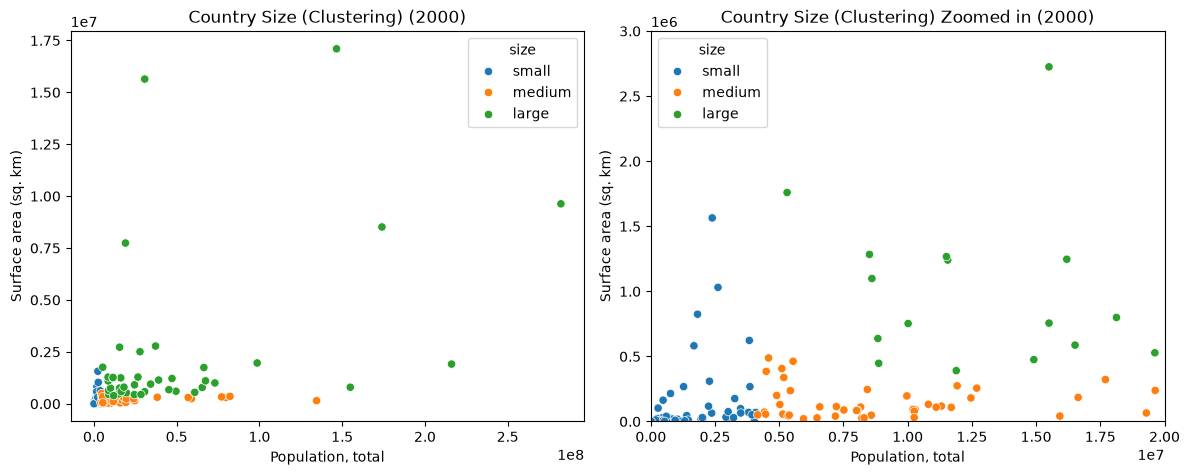

In [39]:
graphic_df = final_df[final_df['year'] == 2000].sort_values('size', ascending = False)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
g1 = sns.scatterplot(data = graphic_df, x = 'Population, total', y = 'Surface area (sq. km)', hue = 'size', ax = axes[0]).set(title = 'Country Size (Clustering) (2000)')
g2 = sns.scatterplot(data = graphic_df, x = 'Population, total', y = 'Surface area (sq. km)', hue = 'size', ax = axes[1]).set(xlim = (0, 0.02 * 10**9), ylim = (0, 0.3 * 10**7), title = 'Country Size (Clustering) Zoomed in (2000)')
plt.tight_layout()
plt.show()

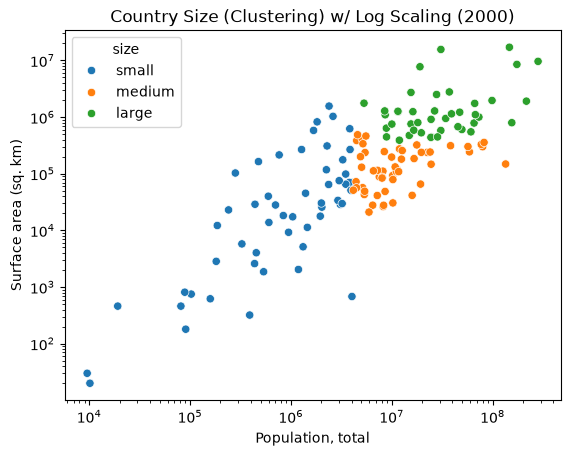

In [40]:
fig, axes = plt.subplots()
g1 = sns.scatterplot(data = graphic_df, x = 'Population, total', y = 'Surface area (sq. km)', hue = 'size', ax = axes).set(title = 'Country Size (Clustering) w/ Log Scaling (2000)')
plt.xscale('log')
plt.yscale('log')
plt.show()